In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv('8-fraud_detection.csv')

In [3]:
df.head()

,transaction_amount,transaction_risk_score,is_fraud
0,1.879910,-1.485035,0
1,0.377083,-2.238585,0
2,1.354312,-2.664638,0
3,-0.509843,-1.502950,0
4,0.863561,-1.906364,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_amount      10000 non-null  float64
 1   transaction_risk_score  10000 non-null  float64
 2   is_fraud                10000 non-null  int64  
dtypes: float64(2), int64(1)
memory usage: 234.5 KB


In [5]:
df['is_fraud'].value_counts()

is_fraud
0    9846
1     154
Name: count, dtype: int64

In [6]:
# imbalanced dataset

In [7]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

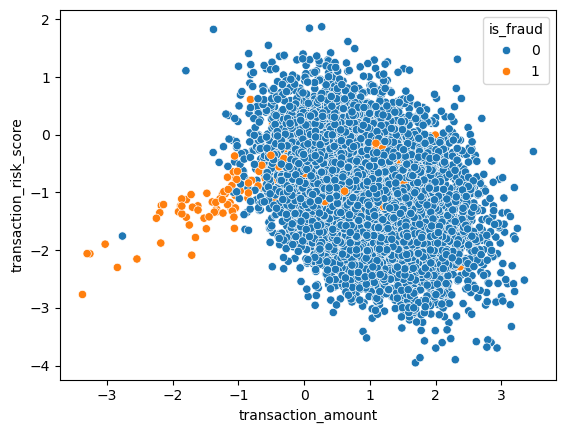

In [8]:
sns.scatterplot(x = X['transaction_amount'], y = X['transaction_risk_score'], hue = y)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [10]:
from sklearn.linear_model import LogisticRegression
logistic = LogisticRegression()

In [11]:
penalty = ['l1', 'l2', 'elasticnet']
c_values = [0.01, 0.1, 1, 10, 100]
solver = ['liblinear', 'saga', 'lbfgs', 'newton-cg', 'sag', 'newton-cholesky']
class_weight = [{0:w, 1:y} for w in [1, 10, 50, 100] for y in [1, 10, 50, 100]]
class_weight

[{0: 1, 1: 1},
 {0: 1, 1: 10},
 {0: 1, 1: 50},
 {0: 1, 1: 100},
 {0: 10, 1: 1},
 {0: 10, 1: 10},
 {0: 10, 1: 50},
 {0: 10, 1: 100},
 {0: 50, 1: 1},
 {0: 50, 1: 10},
 {0: 50, 1: 50},
 {0: 50, 1: 100},
 {0: 100, 1: 1},
 {0: 100, 1: 10},
 {0: 100, 1: 50},
 {0: 100, 1: 100}]

In [12]:
params = dict(penalty=penalty, C=c_values, solver=solver, class_weight=class_weight)

In [13]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [14]:
cv = StratifiedKFold()

In [15]:
grid = GridSearchCV(estimator=logistic, param_grid=params, cv=cv, n_jobs=-1, scoring='accuracy')

In [16]:
import warnings
warnings.filterwarnings('ignore')

In [17]:
grid.fit(X_train, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=False),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                          {0: 1, 1: 50}, {0: 1, 1: 100},
                                          {0: 10, 1: 1}, {0: 10, 1: 10},
                                          {0: 10, 1: 50}, {0: 10, 1: 100},
                                          {0: 50, 1: 1}, {0: 50, 1: 10},
                                          {0: 50, 1: 50}, {0: 50, 1: 100},
                                          {0: 100, 1: 1}, {0: 100, 1: 10},
                                          {0: 100, 1: 50}, {0: 100, 1: 100}],
                         'penalty': ['l1', 'l2', 'elasticnet'],
                         'solver': ['liblinear', 'saga', 'lbfgs', 'newton-cg',
                                    'sag', 'newton-cholesky']},
             scoring='accuracy')

In [18]:
y_pred = grid.predict(X_test)

In [19]:
y_pred

array([0, 0, 0, ..., 0, 0, 0], dtype=int64)

In [20]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [21]:
print('Accuracy Score:', accuracy_score(y_pred, y_test))
print('Classification Report:\n', classification_report(y_pred, y_test))
print('Confusion Matrix:\n', confusion_matrix(y_pred, y_test))

Accuracy Score: 0.99
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      0.99      2481
           1       0.42      0.84      0.56        19

    accuracy                           0.99      2500
   macro avg       0.71      0.92      0.78      2500
weighted avg       0.99      0.99      0.99      2500

Confusion Matrix:
 [[2459   22]
 [   3   16]]


In [22]:
grid.best_params_

{'C': 0.01,
 'class_weight': {0: 10, 1: 50},
 'penalty': 'l2',
 'solver': 'newton-cg'}

In [23]:
grid.best_score_

0.9884000000000001

In [24]:
# roc, auc

In [25]:
model_prob = grid.predict_proba(X_test)

In [26]:
model_prob = model_prob[:, 1]
# probability for the positive (fraud) class

In [27]:
model_prob

array([0.00413564, 0.14712991, 0.047692  , ..., 0.01101025, 0.01545863,
       0.00241266])

In [28]:
from sklearn.metrics import roc_auc_score, roc_curve

In [29]:
model_auc = roc_auc_score(y_test, model_prob)

In [30]:
model_auc

0.7392898371029116

In [31]:
roc_curve(y_test, model_prob)

(array([0.        , 0.        , 0.        , 0.00121852, 0.00121852,
        0.00812348, 0.00812348, 0.0170593 , 0.0170593 , 0.04711617,
        0.04711617, 0.04752234, 0.04752234, 0.07879773, 0.07879773,
        0.17587327, 0.17587327, 0.2469537 , 0.2469537 , 0.26766856,
        0.26766856, 0.33956133, 0.33956133, 0.35337124, 0.35337124,
        0.46709992, 0.46709992, 0.52883834, 0.52883834, 0.53533712,
        0.53533712, 0.55767669, 0.55767669, 0.66368806, 0.66368806,
        0.7095857 , 0.7095857 , 0.74045491, 0.74045491, 0.79203899,
        0.79203899, 0.80950447, 0.80950447, 0.82859464, 0.82859464,
        0.8338749 , 0.8338749 , 0.85702681, 0.85702681, 1.        ]),
 array([0.        , 0.02631579, 0.39473684, 0.39473684, 0.42105263,
        0.42105263, 0.44736842, 0.44736842, 0.47368421, 0.47368421,
        0.5       , 0.5       , 0.52631579, 0.52631579, 0.55263158,
        0.55263158, 0.57894737, 0.57894737, 0.60526316, 0.60526316,
        0.63157895, 0.63157895, 0.65789474, 0.

In [33]:
# model true positive rate
# model false positive rate
model_fpr, model_tpr, thresholds = roc_curve(y_test, model_prob)

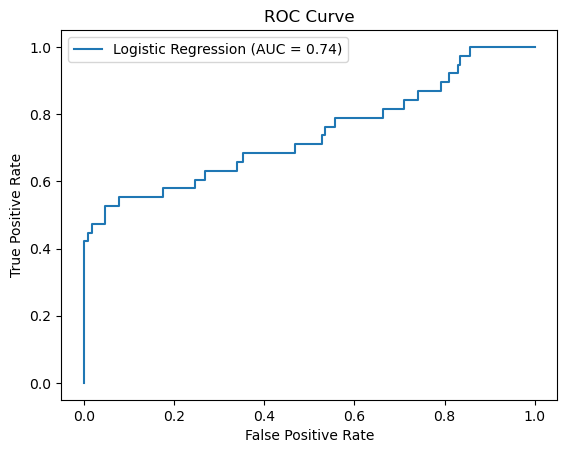

In [34]:
plt.plot(model_fpr, model_tpr, label='Logistic Regression (AUC = {:.2f})'.format(model_auc))
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

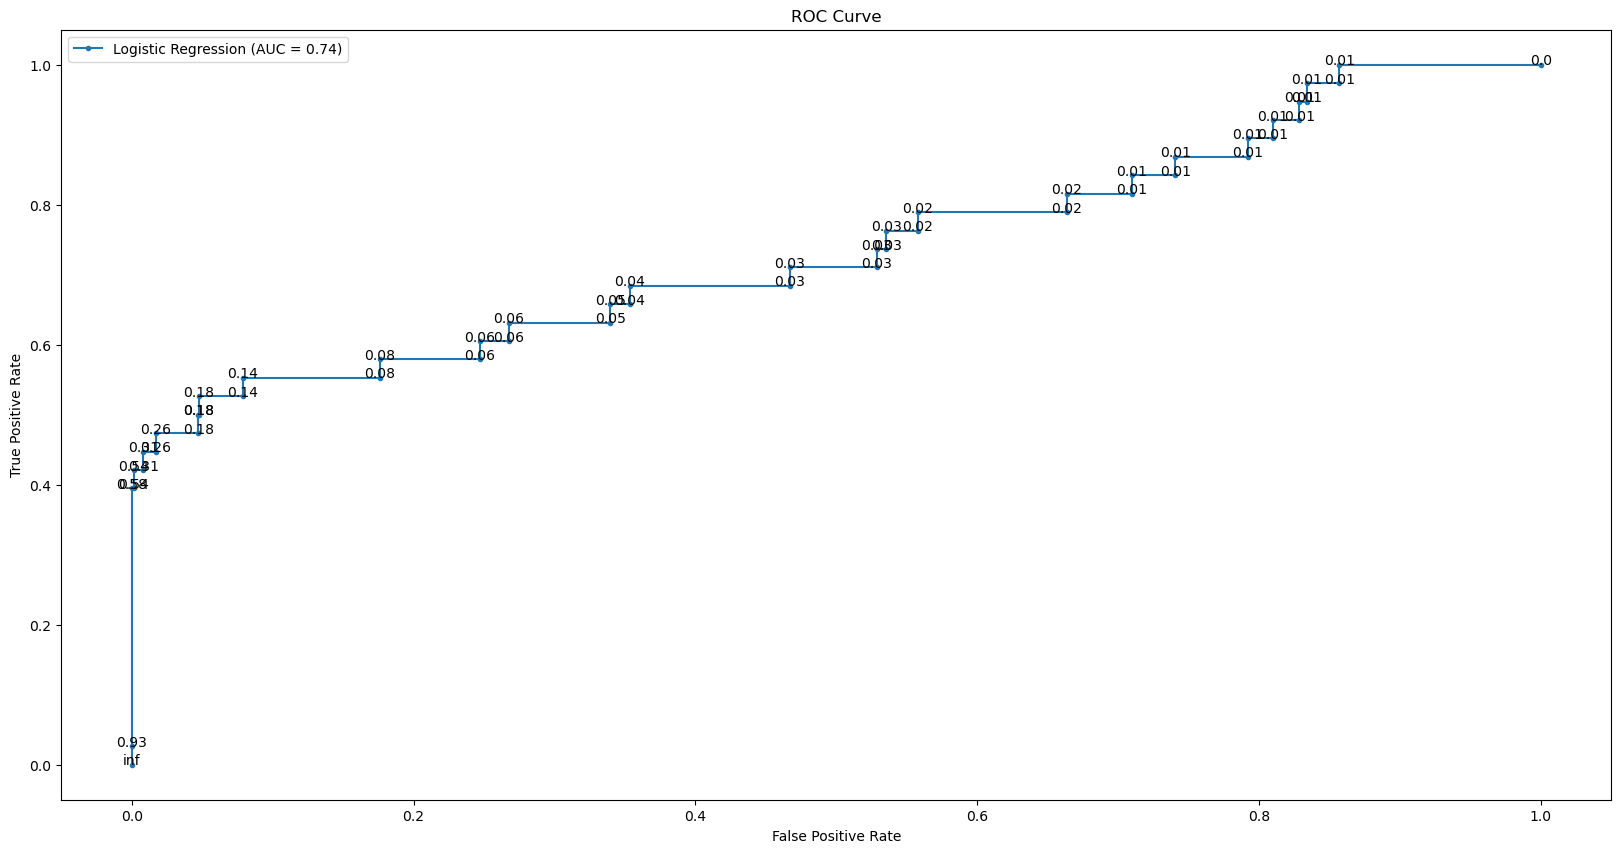

In [35]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(model_fpr, model_tpr, label='Logistic Regression (AUC = {:.2f})'.format(model_auc), marker='.')
for fpr, tpr, thresh in zip(model_fpr, model_tpr, thresholds):
    ax.annotate(f'{np.round(thresh, 2)}', (fpr, tpr), ha='center')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve')
ax.legend()
plt.show()

In [40]:
custom_threshold = 0.5
y_pred_custom = (model_prob >= custom_threshold).astype(int)

In [41]:
y_pred_custom

array([0, 0, 0, ..., 0, 0, 0])

In [42]:
print(confusion_matrix(y_pred_custom, y_test))
print(classification_report(y_pred_custom, y_test))

[[2459   22]
 [   3   16]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      2481
           1       0.42      0.84      0.56        19

    accuracy                           0.99      2500
   macro avg       0.71      0.92      0.78      2500
weighted avg       0.99      0.99      0.99      2500

